In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
a = pd.read_csv(r"C:\Users\111\Desktop\qihui_obs_update.csv")
print(a.columns)  # 打印列名以确认数据结构

print(a.head())  # 打印前几行数据以检查内容


Index(['Datetime', 'radi', 'Power', 'theory'], dtype='object')
              Datetime  radi  Power  theory
0  2024-10-25 00:00:00   0.0    0.0  -999.0
1  2024-10-25 00:15:00   0.0    0.0  -999.0
2  2024-10-25 00:30:00   0.0    0.0  -999.0
3  2024-10-25 00:45:00   0.0    0.0  -999.0
4  2024-10-25 01:00:00   0.0    0.0  -999.0



开始提取卫星数据(UTC时间)...
找到 746 个TIFF文件...


处理进度: 100%|██████████| 746/746 [00:06<00:00, 110.15it/s] 



有效卫星数据点数(11月及之后): 476/746

处理地面观测数据(北京时间)...
有效地面观测点数: 1976

对比图已保存至: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\output_plots\启辉_辐射对比_北京时间.png


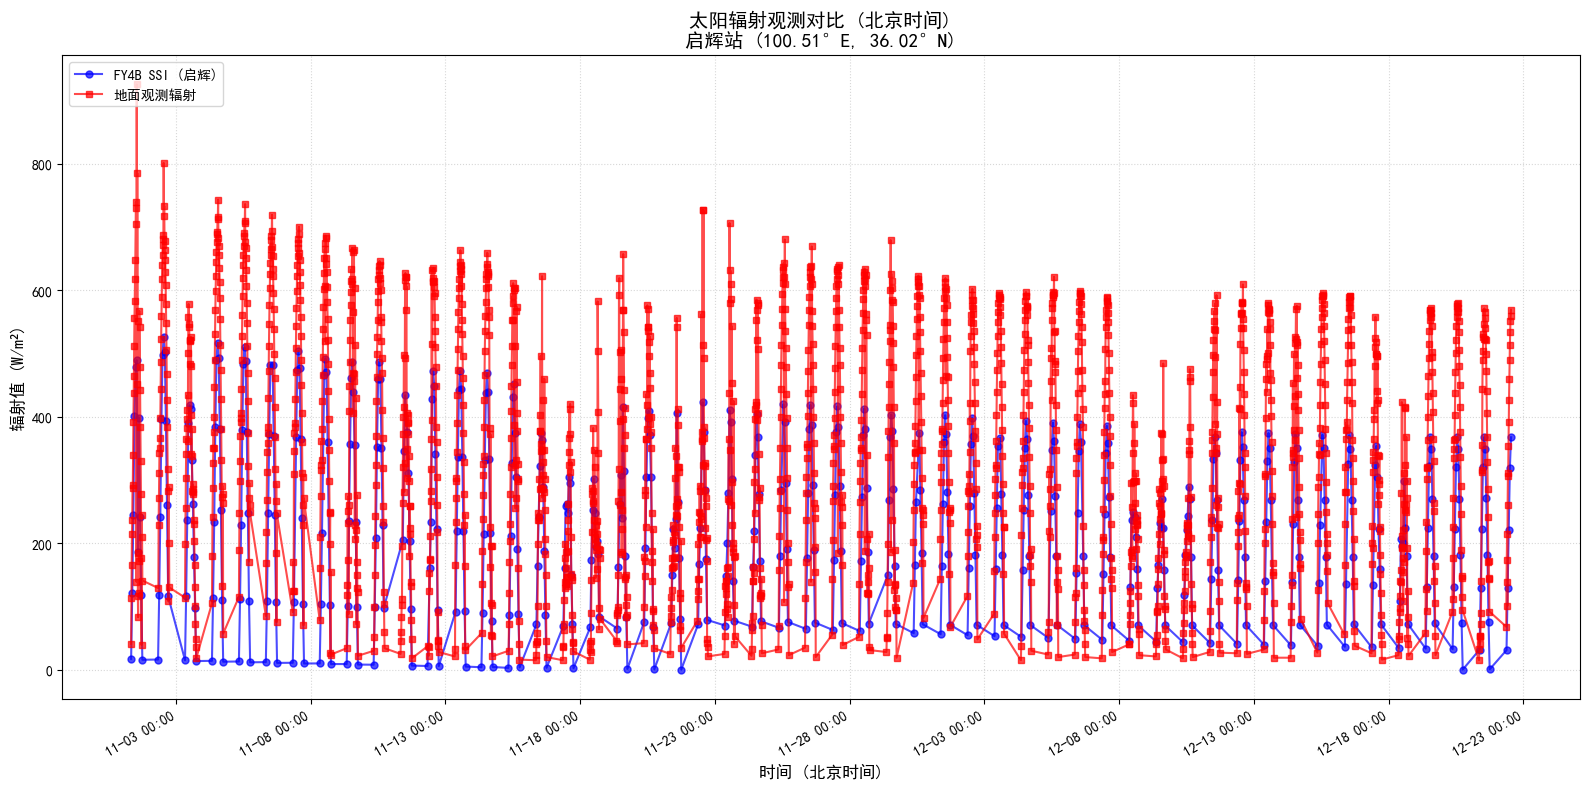

In [1]:
import os
import glob
import pandas as pd
from datetime import datetime, timedelta
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import pytz

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==================== 配置参数 ====================
# 站点信息
STATION_NAME = "启辉"
STATION_LON, STATION_LAT = 100.51, 36.02  # 经纬度

# 路径配置
BASE_PATH = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
CSV_PATH = r"C:\Users\111\Desktop\qihui_obs_update.csv"
OUTPUT_DIR = os.path.join(BASE_PATH, "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 时间参数
START_MONTH = 11  # 只处理11月及之后的数据
UTC_TO_CST = timedelta(hours=8)  # UTC转北京时间偏移量

# SSI验证参数
SSI_VALID_RANGE = (0, 1500)  # 合理物理范围 (W/m²)
NODATA_VALUES = [-9999, 65535, np.nan]  # 无效值标记

# ==================== 函数定义 ====================
def safe_extract_ssi(tif_file, lon, lat):
    """安全提取SSI值，包含严格验证"""
    try:
        with rasterio.open(tif_file) as src:
            data = src.read(1)
            row, col = src.index(lon, lat)
            
            # 边界检查
            if not (0 <= row < data.shape[0] and 0 <= col < data.shape[1]):
                return None
                
            value = data[row, col]
            
            # 有效性验证
            if (value in NODATA_VALUES) or (not SSI_VALID_RANGE[0] <= value <= SSI_VALID_RANGE[1]):
                return None
                
            return float(value)
    except Exception as e:
        print(f"处理失败 {os.path.basename(tif_file)}: {str(e)}")
        return None

def parse_time(filename):
    """从文件名解析时间并转换为北京时间"""
    try:
        datetime_str = filename.split('_')[-2][:10]  # 提取前10位 (YYYYMMDDHH)
        utc_time = datetime.strptime(datetime_str, "%Y%m%d%H")
        
        # 只保留11月及之后的数据
        if utc_time.month < START_MONTH:
            return None
            
        # UTC转北京时间
        return utc_time + UTC_TO_CST
    except:
        return None

def process_obs_data(csv_path, start_time=None, end_time=None):
    """处理地面观测数据，返回北京时间DataFrame"""
    try:
        # 读取CSV并解析时间
        obs_df = pd.read_csv(
            csv_path,
            parse_dates=['Datetime'],
            date_format='mixed'
        )
        
        # 确保时间列是datetime类型
        obs_df['Datetime'] = pd.to_datetime(obs_df['Datetime'], errors='coerce')
        obs_df = obs_df.dropna(subset=['Datetime'])
        
        # 假设CSV中的时间已经是北京时间，无需转换
        # 过滤无效值和指定时间范围
        obs_df = obs_df[obs_df['radi'] > 0]
        
        if start_time and end_time:
            obs_df = obs_df[
                (obs_df['Datetime'] >= start_time) & 
                (obs_df['Datetime'] <= end_time)
            ]
            
        return obs_df
    except Exception as e:
        print(f"地面观测数据处理失败: {str(e)}")
        return pd.DataFrame()

# ==================== 主流程 ====================
if __name__ == "__main__":
    # 1. 处理卫星数据 (UTC时间)
    print("\n开始提取卫星数据(UTC时间)...")
    tif_files = glob.glob(os.path.join(BASE_PATH, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*.TIF"), recursive=True)
    print(f"找到 {len(tif_files)} 个TIFF文件...")
    
    ssi_data = []
    for tif_file in tqdm(tif_files, desc="处理进度"):
        cst_time = parse_time(os.path.basename(tif_file))  # 返回的已经是北京时间
        if not cst_time:
            continue
            
        ssi = safe_extract_ssi(tif_file, STATION_LON, STATION_LAT)
        if ssi is not None:
            ssi_data.append({'time': cst_time, 'ssi': ssi})

    # 转换为DataFrame
    ssi_df = pd.DataFrame(ssi_data).sort_values('time').drop_duplicates('time')
    print(f"\n有效卫星数据点数(11月及之后): {len(ssi_df)}/{len(tif_files)}")
    
    # 2. 处理地面观测数据 (北京时间)
    print("\n处理地面观测数据(北京时间)...")
    obs_df = process_obs_data(
        CSV_PATH,
        start_time=ssi_df['time'].min() if not ssi_df.empty else None,
        end_time=ssi_df['time'].max() if not ssi_df.empty else None
    )
    print(f"有效地面观测点数: {len(obs_df)}")

    # 3. 时间序列绘图
    if not ssi_df.empty:
        plt.figure(figsize=(16, 8))
        
        # 绘制卫星数据 (已转换为北京时间)
        plt.plot(ssi_df['time'], ssi_df['ssi'], 
                 'b-', marker='o', markersize=5, 
                 label=f'FY4B SSI ({STATION_NAME})', alpha=0.7)
        
        # 绘制地面观测数据
        if not obs_df.empty:
            plt.plot(obs_df['Datetime'], obs_df['radi'], 
                     'r-', marker='s', markersize=4, 
                     label='地面观测辐射', alpha=0.7)
        
        # 图形美化
        plt.title(f'太阳辐射观测对比 (北京时间)\n{STATION_NAME}站 ({STATION_LON}°E, {STATION_LAT}°N)', fontsize=14)
        plt.xlabel('时间 (北京时间)', fontsize=12)
        plt.ylabel('辐射值 (W/m²)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.5)
        
        # 时间轴设置
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        plt.gcf().autofmt_xdate()
        
        plt.legend(fontsize=10, loc='upper left')
        plt.tight_layout()
        
        # 保存图片
        output_path = os.path.join(OUTPUT_DIR, f"{STATION_NAME}_辐射对比_北京时间.png")
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"\n对比图已保存至: {output_path}")
        plt.show()

    # 4. 保存处理结果
    if not ssi_df.empty:
        ssi_df.to_csv(os.path.join(OUTPUT_DIR, "ssi_data_cst.csv"), index=False)
    if not obs_df.empty:
        obs_df.to_csv(os.path.join(OUTPUT_DIR, "obs_data_cst.csv"), index=False)

文件基本信息:
文件路径: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\202410\20241001\20241001010000\MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001010000_0000-0000.TIF
驱动: GTiff
波段数量: 1
图像宽度: 1540
图像高度: 1181
数据类型: float32

地理参考信息:
坐标参考系统(CRS): EPSG:4326
变换矩阵(transform): | 0.04, 0.00, 73.50|
| 0.00,-0.04, 53.56|
| 0.00, 0.00, 1.00|
边界范围(bounds): BoundingBox(left=73.5009857599408, bottom=6.320261104868202, right=135.1009857599408, top=53.560261104868204)

数据统计信息:
最小值: 0.013501317240297794
最大值: 617.0640869140625
平均值: 199.30787658691406
中位数: 185.81253051757812
标准差: 118.25670623779297

无效值检查:
无效值(NODATA): nan
无效值数量: 0

生成预览图...


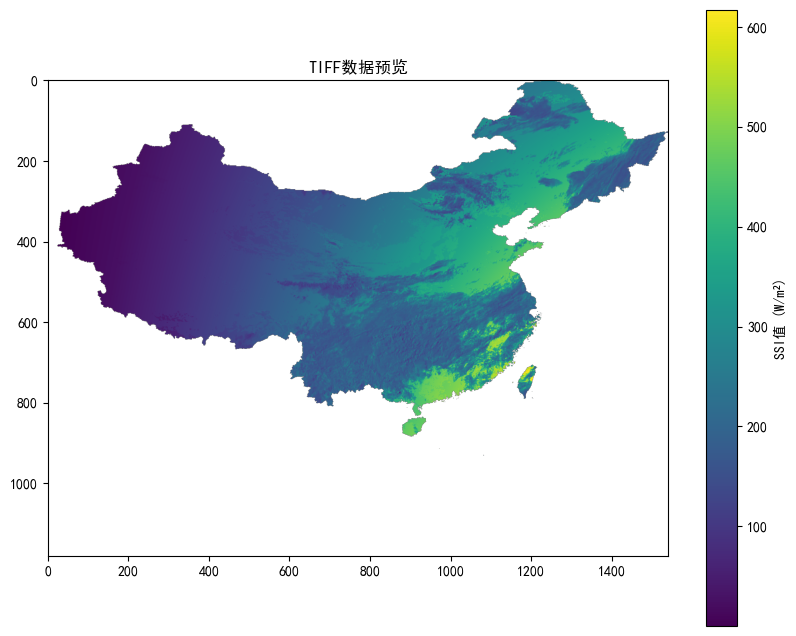


完整元数据:
{'AREA_OR_POINT': 'Area'}
波段元数据:
{}


In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 指定TIFF文件路径
tif_path =r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\202410\20241001\20241001010000\MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001010000_0000-0000.TIF"

# 打开TIFF文件并读取元数据
with rasterio.open(tif_path) as src:
    # 1. 基本信息
    print("="*50)
    print("文件基本信息:")
    print(f"文件路径: {tif_path}")
    print(f"驱动: {src.driver}")
    print(f"波段数量: {src.count}")
    print(f"图像宽度: {src.width}")
    print(f"图像高度: {src.height}")
    print(f"数据类型: {src.dtypes[0]}")
    
    # 2. 地理参考信息（如果是GeoTIFF）
    print("\n" + "="*50)
    print("地理参考信息:")
    print(f"坐标参考系统(CRS): {src.crs}")
    print(f"变换矩阵(transform): {src.transform}")
    print(f"边界范围(bounds): {src.bounds}")
    
    # 3. 数据统计信息
    print("\n" + "="*50)
    print("数据统计信息:")
    data = src.read(1)  # 读取第一个波段
    print(f"最小值: {np.nanmin(data)}")
    print(f"最大值: {np.nanmax(data)}")
    print(f"平均值: {np.nanmean(data)}")
    print(f"中位数: {np.nanmedian(data)}")
    print(f"标准差: {np.nanstd(data)}")
    
    # 4. 检查无效值
    print("\n" + "="*50)
    print("无效值检查:")
    print(f"无效值(NODATA): {src.nodatavals[0]}")
    print(f"无效值数量: {np.sum(data == src.nodatavals[0])}")
    
    # 5. 可视化
    print("\n" + "="*50)
    print("生成预览图...")
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap='viridis')
    plt.colorbar(label='SSI值 (W/m²)')
    plt.title("TIFF数据预览")
    plt.show()

    # 6. 元数据（所有标签）
    print("\n" + "="*50)
    print("完整元数据:")
    print(src.tags())
    print("波段元数据:")
    print(src.tags(1))  # 第一个波段的元数据

In [10]:
import pandas as pd
import numpy as np

def analyze_radi_data(csv_path):
    """
    读取CSV文件并计算radi列的统计信息
    
    参数:
        csv_path: CSV文件路径
    返回:
        包含统计信息的字典（若失败则返回None）
    """
    try:
        # 读取CSV文件，自动解析日期列（若有）
        # 假设日期列名为'Datetime'，可根据实际情况修改
        df = pd.read_csv(
            csv_path,
            parse_dates=['Datetime'],  # 解析日期列（若存在）
            date_format='mixed',       # 处理多种日期格式
            na_values=['', ' ', 'NaN'] # 识别无效值
        )
        
        # 检查是否包含'radi'列
        if 'radi' not in df.columns:
            print(f"错误：CSV文件中未找到'radi'列，请检查列名是否正确。")
            return None
        
        # 提取radi列并过滤无效值（如负数、NaN）
        radi_data = df['radi'].dropna()  # 删除空值
        radi_data = radi_data[radi_data >= 0]  # 辐射值不能为负（根据物理意义过滤）
        
        if len(radi_data) == 0:
            print("警告：经过过滤后，'radi'列无有效数据。")
            return None
        
        # 计算统计指标
        stats = {
            '数据总量': len(df['radi']),  # 原始数据总数
            '有效数据量': len(radi_data),  # 过滤后有效数据数
            '缺失值数量': len(df['radi']) - len(radi_data.dropna()),  # 空值数量
            '最小值': round(radi_data.min(), 3),
            '最大值': round(radi_data.max(), 3),
            '平均值': round(radi_data.mean(), 3),
            '中位数': round(radi_data.median(), 3),
            '标准差': round(radi_data.std(), 3),  # 数据离散程度
            '方差': round(radi_data.var(), 3),    # 标准差的平方
            '25%分位数': round(radi_data.quantile(0.25), 3),  # 25%的数据小于该值
            '75%分位数': round(radi_data.quantile(0.75), 3)   # 75%的数据小于该值
        }
        
        # 打印统计结果
        print("===== 'radi'列统计信息 =====")
        for key, value in stats.items():
            print(f"{key}: {value}")
        
        return stats
    
    except FileNotFoundError:
        print(f"错误：文件未找到，请检查路径是否正确：{csv_path}")
        return None
    except Exception as e:
        print(f"处理CSV时发生错误：{str(e)}")
        return None

# ==================== 主程序 ====================
if __name__ == "__main__":
    # 替换为你的CSV文件路径
    csv_path = r"C:\Users\111\Desktop\qihui_obs_update.csv"
    # 调用函数计算统计信息
    analyze_radi_data(csv_path)

===== 'radi'列统计信息 =====
数据总量: 50597
有效数据量: 50594
缺失值数量: 3
最小值: 0.0
最大值: 968.0
平均值: 210.367
中位数: 0.0
标准差: 282.355
方差: 79724.484
25%分位数: 0.0
75%分位数: 416.915



开始提取卫星数据(UTC时间)...
找到 742 个TIFF文件...


处理进度: 100%|██████████| 742/742 [00:09<00:00, 80.28it/s]  



有效卫星数据点数(11月及之后): 468/742

处理地面观测数据(北京时间)...
有效地面观测点数: 1972

对比图已保存至: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\output_plots\启辉_辐射对比_北京时间.png


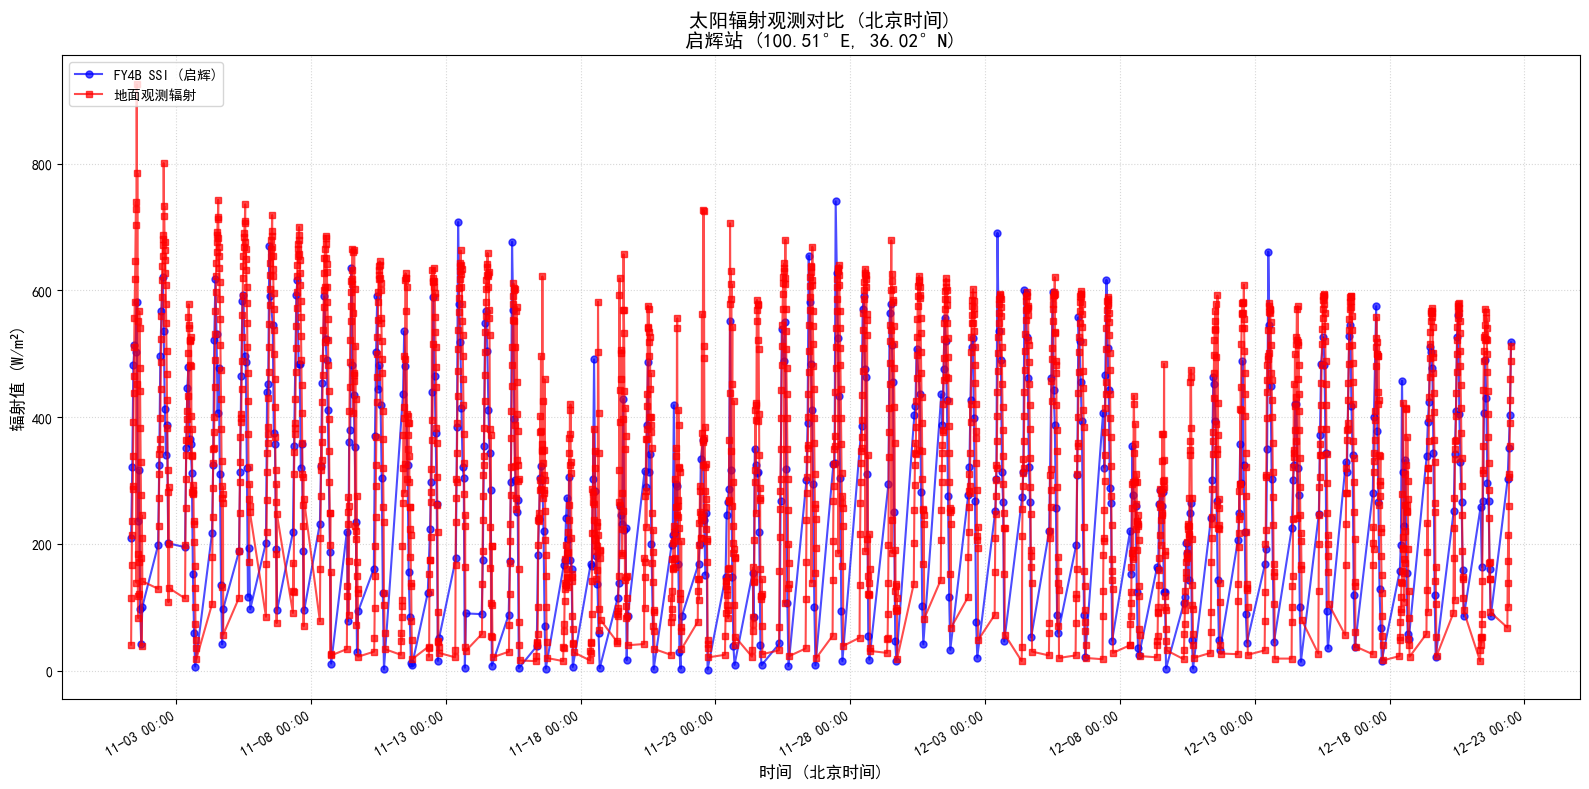

In [1]:
import os
import glob
import pandas as pd
from datetime import datetime, timedelta
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import pytz

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==================== 配置参数 ====================
# 站点信息
STATION_NAME = "启辉"
STATION_LON, STATION_LAT = 100.51, 36.02  # 经纬度

# 路径配置
BASE_PATH = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
CSV_PATH = r"C:\Users\111\Desktop\qihui_obs_update.csv"
OUTPUT_DIR = os.path.join(BASE_PATH, "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 时间参数
START_MONTH = 11  # 只处理11月及之后的数据
UTC_TO_CST = timedelta(hours=8)  # UTC转北京时间偏移量

# SSI验证参数
SSI_VALID_RANGE = (0, 1500)  # 合理物理范围 (W/m²)
NODATA_VALUES = [-9999, 65535, np.nan]  # 无效值标记

# ==================== 函数定义 ====================
def safe_extract_ssi(tif_file, lon, lat):
    """安全提取SSI值，包含严格验证"""
    try:
        with rasterio.open(tif_file) as src:
            data = src.read(1)
            row, col = src.index(lon, lat)
            
            # 边界检查
            if not (0 <= row < data.shape[0] and 0 <= col < data.shape[1]):
                return None
                
            value = data[row, col]
            
            # 有效性验证
            if (value in NODATA_VALUES) or (not SSI_VALID_RANGE[0] <= value <= SSI_VALID_RANGE[1]):
                return None
                
            return float(value)
    except Exception as e:
        print(f"处理失败 {os.path.basename(tif_file)}: {str(e)}")
        return None

def parse_time(filename):
    """从文件名解析时间并转换为北京时间"""
    try:
        datetime_str = filename.split('_')[-2][:10]  # 提取前10位 (YYYYMMDDHH)
        utc_time = datetime.strptime(datetime_str, "%Y%m%d%H")
        
        # 只保留11月及之后的数据
        if utc_time.month < START_MONTH:
            return None
            
        # UTC转北京时间
        return utc_time + UTC_TO_CST
    except:
        return None

def process_obs_data(csv_path, start_time=None, end_time=None):
    """处理地面观测数据，返回北京时间DataFrame"""
    try:
        # 读取CSV并解析时间
        obs_df = pd.read_csv(
            csv_path,
            parse_dates=['Datetime'],
            date_format='mixed'
        )
        
        # 确保时间列是datetime类型
        obs_df['Datetime'] = pd.to_datetime(obs_df['Datetime'], errors='coerce')
        obs_df = obs_df.dropna(subset=['Datetime'])
        
        # 假设CSV中的时间已经是北京时间，无需转换
        # 过滤无效值和指定时间范围
        obs_df = obs_df[obs_df['radi'] > 0]
        
        if start_time and end_time:
            obs_df = obs_df[
                (obs_df['Datetime'] >= start_time) & 
                (obs_df['Datetime'] <= end_time)
            ]
            
        return obs_df
    except Exception as e:
        print(f"地面观测数据处理失败: {str(e)}")
        return pd.DataFrame()

# ==================== 主流程 ====================
if __name__ == "__main__":
    # 1. 处理卫星数据 (UTC时间)
    print("\n开始提取卫星数据(UTC时间)...")
    tif_files = glob.glob(os.path.join(BASE_PATH, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000*.TIF"), recursive=True)
    print(f"找到 {len(tif_files)} 个TIFF文件...")
    
    ssi_data = []
    for tif_file in tqdm(tif_files, desc="处理进度"):
        cst_time = parse_time(os.path.basename(tif_file))  # 返回的已经是北京时间
        if not cst_time:
            continue
            
        ssi = safe_extract_ssi(tif_file, STATION_LON, STATION_LAT)
        if ssi is not None:
            ssi_data.append({'time': cst_time, 'ssi': ssi})

    # 转换为DataFrame
    ssi_df = pd.DataFrame(ssi_data).sort_values('time').drop_duplicates('time')
    print(f"\n有效卫星数据点数(11月及之后): {len(ssi_df)}/{len(tif_files)}")
    
    # 2. 处理地面观测数据 (北京时间)
    print("\n处理地面观测数据(北京时间)...")
    obs_df = process_obs_data(
        CSV_PATH,
        start_time=ssi_df['time'].min() if not ssi_df.empty else None,
        end_time=ssi_df['time'].max() if not ssi_df.empty else None
    )
    print(f"有效地面观测点数: {len(obs_df)}")

    # 3. 时间序列绘图
    if not ssi_df.empty:
        plt.figure(figsize=(16, 8))
        
        # 绘制卫星数据 (已转换为北京时间)
        plt.plot(ssi_df['time'], ssi_df['ssi'], 
                 'b-', marker='o', markersize=5, 
                 label=f'FY4B SSI ({STATION_NAME})', alpha=0.7)
        
        # 绘制地面观测数据
        if not obs_df.empty:
            plt.plot(obs_df['Datetime'], obs_df['radi'], 
                     'r-', marker='s', markersize=4, 
                     label='地面观测辐射', alpha=0.7)
        
        # 图形美化
        plt.title(f'太阳辐射观测对比 (北京时间)\n{STATION_NAME}站 ({STATION_LON}°E, {STATION_LAT}°N)', fontsize=14)
        plt.xlabel('时间 (北京时间)', fontsize=12)
        plt.ylabel('辐射值 (W/m²)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.5)
        
        # 时间轴设置
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        plt.gcf().autofmt_xdate()
        
        plt.legend(fontsize=10, loc='upper left')
        plt.tight_layout()
        
        # 保存图片
        output_path = os.path.join(OUTPUT_DIR, f"{STATION_NAME}_辐射对比_北京时间.png")
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"\n对比图已保存至: {output_path}")
        plt.show()

    # 4. 保存处理结果
    if not ssi_df.empty:
        ssi_df.to_csv(os.path.join(OUTPUT_DIR, "ssi_data_cst.csv"), index=False)
    if not obs_df.empty:
        obs_df.to_csv(os.path.join(OUTPUT_DIR, "obs_data_cst.csv"), index=False)